In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.impute import KNNImputer
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pathlib import Path
import sys

PROJECT_ROOT = Path(r"C:\Users\devan\Desktop\SAR_Work")  # 👈 must contain PKL_file
sys.path.append(str(PROJECT_ROOT))
from PKL_file import WeeklyProfileFeatureBuilder

In [2]:
path = r'..\Data\Original_Data\Motot_Type_YWNC-203.xlsx'
df = pd.read_excel(path)

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
mask = df["Time"].astype(str).str.contains(", 24:")

# fix time: replace 24 with 00
df.loc[mask, "Time"] = (
    df.loc[mask, "Time"]
      .str.replace(", 24:", ", 00:", n=1)
)

# Convert datetime type data
df["Time"] = pd.to_datetime(df["Time"], format="%d/%m/%Y, %H:%M:%S")

# Short by time (Important for energy data)
df = df.sort_values('Time')

# Set time as index
df = df.set_index('Time')

In [5]:
time_diff = df.index.to_series().diff()
time_diff.describe()

count                        63063
mean     0 days 00:04:24.995892995
std      0 days 00:45:38.966934876
min                0 days 00:00:10
25%                0 days 00:02:38
50%                0 days 00:05:03
75%                0 days 00:05:09
max                5 days 23:49:23
Name: Time, dtype: object

In [6]:
df['gap_hours'] = df.index.to_series().diff().dt.total_seconds() / 3600
df[df['gap_hours'] > 1]

,TOTAL_NET_KWH,AVG_CURRENT,AVG_V_LL,AVG_V_LN,FREQUENCY,Type,gap_hours
Time,,,,,,,
2025-07-28 16:14:03,15733.282,4.733,398.109,229.908,49.978,YWNC-203,1.641111
2025-08-24 12:59:15,8560.961,3.952,402.293,232.297,50.122,YWNC-203,1.122500
2025-09-01 12:25:32,8766.806,4.035,400.025,231.019,50.127,YWNC-203,143.823056
2025-09-06 16:12:43,8907.466,0.420,415.626,239.980,49.947,YWNC-203,5.825556
2025-09-07 18:55:42,8910.984,0.543,416.012,240.203,49.756,YWNC-203,2.981389
2025-10-02 14:11:41,9573.029,0.422,415.340,239.817,50.084,YWNC-203,6.541944
2025-12-07 23:40:06,11309.498,0.621,416.169,240.290,49.987,YWNC-203,1.979444
2025-12-09 14:03:47,11324.952,3.906,402.609,232.476,49.965,YWNC2 CONE,18.533056
2026-01-07 12:40:21,12084.195,3.833,399.129,230.407,50.045,YWNC2 CONE,123.643333


In [7]:
df["KWH_Diff"] = df["TOTAL_NET_KWH"].diff()
df['KWH_Diff'] = df['KWH_Diff'].where(df['KWH_Diff'] >= 0)

In [8]:
df.isnull().sum()

TOTAL_NET_KWH    0
AVG_CURRENT      0
AVG_V_LL         0
AVG_V_LN         0
FREQUENCY        0
Type             0
gap_hours        1
KWH_Diff         2
dtype: int64

In [9]:
df[df['KWH_Diff'] > 0.4].shape

(43, 8)

In [10]:
df.loc[df["KWH_Diff"] > 0.4, "KWH_Diff"] = np.nan

In [11]:
df["hour"] = df.index.hour
df["weekday"] = df.index.weekday

In [12]:
# Features to use for imputation
features = ["AVG_CURRENT", "AVG_V_LN", "hour", "weekday", "KWH_Diff"]

# Step 1: Fit scaler ONLY on complete rows (no missing KWH_Diff)
mask = df["KWH_Diff"].notna()
scaler = StandardScaler()
scaler.fit(df.loc[mask, features])

# Step 2: Scale all data
scaled = scaler.transform(df[features])

# Step 3: Impute
imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_scaled = imputer.fit_transform(scaled)

# Step 4: Inverse transform and update original dataframe
imputed = scaler.inverse_transform(imputed_scaled)
df["KWH_Diff"] = imputed[:, -1]

In [13]:
imputed[:, -1]

array([0.07621093, 0.09      , 0.093     , ..., 0.03      , 0.033     ,
       0.033     ], shape=(63064,))

In [14]:
df[df["KWH_Diff"] > 0.3].shape

(138, 10)

In [15]:
df.isna().sum()

TOTAL_NET_KWH    0
AVG_CURRENT      0
AVG_V_LL         0
AVG_V_LN         0
FREQUENCY        0
Type             0
gap_hours        1
KWH_Diff         0
hour             0
weekday          0
dtype: int64

### Resampling of the data

In [16]:
hourly_df = (
    df
    .resample('1H')
    .agg({
        'KWH_Diff': 'sum',
        'AVG_CURRENT': 'mean',
        'AVG_V_LN': 'mean'
    })
)
hourly_df.rename(columns={'KWH_Diff':"HOURLY_KWH"}, inplace=True)

# Optional: Track which hours have no original data
hourly_df['original_data'] = hourly_df['AVG_CURRENT'].notna()

C:\Users\devan\AppData\Local\Temp\ipykernel_16844\245775366.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


In [17]:
hourly_df.isna().sum()

HOURLY_KWH         0
AVG_CURRENT      307
AVG_V_LN         307
original_data      0
dtype: int64

In [18]:
# Set HOURLY_KWH to NaN wherever AVG_CURRENT is NaN
hourly_df.loc[hourly_df['AVG_CURRENT'].isna(), 'HOURLY_KWH'] = np.nan

#### Handling the gaps with the mean values of columns with respective Week day and hours

In [19]:
hourly_df["weekday"] = hourly_df.index.weekday   # Monday=0
hourly_df["hour"] = hourly_df.index.hour

In [20]:
# What has this machine usually consumed on this weekday at this hour, based only on what I’ve seen so far?
def fill_past_mean(s):
    result = s.expanding(min_periods=2).mean()
    return s.fillna(result)

for col in ["HOURLY_KWH", "AVG_CURRENT", "AVG_V_LN"]:
    hourly_df[col] = (
        hourly_df
        .groupby(["weekday", "hour"])[col]
        .transform(fill_past_mean)
    )

In [21]:
# Drop the temp columns
hourly_df = hourly_df.drop(columns=["weekday", "hour"])

In [22]:
hourly_df.loc['2026-01-02 08:00:00':'2026-01-07 13:00:00']

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,original_data
Time,,,,
2026-01-02 08:00:00,1.208000,4.429762,231.161381,True
2026-01-02 09:00:00,0.061000,5.783000,230.859000,True
2026-01-02 10:00:00,1.437714,4.723736,230.376471,False
2026-01-02 11:00:00,1.360318,4.360062,231.324977,False
2026-01-02 12:00:00,1.376773,4.509262,231.924976,False
...,...,...,...,...
2026-01-07 09:00:00,1.511304,4.731336,230.696355,False
2026-01-07 10:00:00,1.495000,4.534103,230.584723,False
2026-01-07 11:00:00,1.419565,4.425622,231.421095,False


In [23]:
hourly_df.head()

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,original_data
Time,,,,
2025-07-22 20:00:00,0.076211,2.445000,237.957000,True
2025-07-22 21:00:00,0.507000,1.151818,234.739273,True
2025-07-22 22:00:00,1.197000,2.508750,233.409417,True
2025-07-22 23:00:00,1.242000,2.655833,234.676667,True
2025-07-23 00:00:00,1.901000,3.879091,234.648636,True


##### FEature Building

In [24]:
def engineer_features(df):
    df = df.copy()

    df["power_proxy"] = df["AVG_CURRENT"] * df["AVG_V_LN"]

    df["hour"] = df.index.hour
    df["weekday"] = df.index.weekday
    df["day_of_month"] = df.index.day
    df["month"] = df.index.month
    df["week_of_year"] = df.index.isocalendar().week

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    # Shift: (A:- 7 to 15)(B:- 15 to 22)(C:- 22 to 7 next day)
    hours = df.index.hour
    # Initialize columns
    df["Shift_A"] = False
    df["Shift_B"] = False
    df["Shift_C"] = False
    # Assign shifts
    df.loc[(hours >= 7) & (hours < 15), "Shift_A"] = True
    df.loc[(hours >= 15) & (hours < 22), "Shift_B"] = True
    df.loc[(hours >= 22) | (hours < 7), "Shift_C"] = True
    
    # df["Off"] feature representing Off time
    # Default
    df["Off"] = False

    # Sunday rule: Shift B & C off on Sunday
    df["Off"] |= (df["Shift_B"] & (df["weekday"] == 6))
    df["Off"] |= (df["Shift_C"] & (hours >= 22) & (df["weekday"] == 6))
    df["Off"] |= (df["Shift_C"] & (hours < 7) & (df["weekday"] == 0))

    # Special off schedule
    off_schedule = {
        "2025-10-01": ["Shift_B", "Shift_C"],
        "2025-10-02": ["Shift_A", "Shift_B", "Shift_C"],
        "2025-08-15": ["Shift_A", "Shift_B", "Shift_C"]
    }

    for date_str, shifts in off_schedule.items():
        date = pd.to_datetime(date_str).date()

        # Mask for the exact off day
        mask_today = df.index.date == date

        # Normal shifts (A & B) → whole day off
        normal_shifts = [s for s in shifts if s != "Shift_C"]
        if normal_shifts:
            df.loc[mask_today, "Off"] |= df.loc[mask_today, normal_shifts].any(axis=1)

        # Shift C → overnight logic
        if "Shift_C" in shifts:
            # Day itself: 22:00–23:59
            df.loc[mask_today, "Off"] |= (
                df.loc[mask_today, "Shift_C"] & (df.loc[mask_today].index.hour >= 22)
            )

            # Next day: 00:00–06:59
            next_day = date + pd.Timedelta(days=1)
            mask_next = df.index.date == next_day

            df.loc[mask_next, "Off"] |= (
                df.loc[mask_next, "Shift_C"] & (df.loc[mask_next].index.hour < 7)
            )
        
        # Final override: if machine is consuming power, it is NOT off
        df.loc[df["HOURLY_KWH"] > 0.5, "Off"] = False

    # Convert boolean flags to integers (0/1)
    bool_cols = ["Shift_A", "Shift_B", "Shift_C", "Off"]
    df[bool_cols] = df[bool_cols].astype(int)

    # Lag values
    for lag in [1, 2, 24, 168]:
        df[f"kwh_lag_{lag}"] = df["HOURLY_KWH"].shift(lag)

    df["kwh_roll_3h_mean"] = df["HOURLY_KWH"].rolling(3, min_periods=1).mean()

    df["kwh_roll_24h_mean"] = df["HOURLY_KWH"].rolling(24, min_periods=12).mean()
    df["kwh_roll_24h_std"] = df["HOURLY_KWH"].rolling(24, min_periods=12).std()
    df["kwh_roll_24h_min"] = df["HOURLY_KWH"].rolling(24, min_periods=12).min()
    df["kwh_roll_24h_max"] = df["HOURLY_KWH"].rolling(24, min_periods=12).max()

    df["kwh_roll_168h_mean"] = df["HOURLY_KWH"].rolling(168, min_periods=84).mean()
    df["kwh_roll_168h_std"] = df["HOURLY_KWH"].rolling(168, min_periods=84).std()

    df["kwh_ratio_to_24h_avg"] = df["HOURLY_KWH"] / (df["kwh_roll_24h_mean"] + 1e-6)
    df["kwh_ratio_to_168h_avg"] = df["HOURLY_KWH"] / (df["kwh_roll_168h_mean"] + 1e-6)

    return df

In [25]:
hourly_df = engineer_features(hourly_df)

In [26]:
hourly_df[(hourly_df['Off'] == 1) & (hourly_df['HOURLY_KWH'] > 1)]

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,weekday,hour,power_proxy,day_of_month,month,week_of_year,hour_sin,...,kwh_lag_168,kwh_roll_3h_mean,kwh_roll_24h_mean,kwh_roll_24h_std,kwh_roll_24h_min,kwh_roll_24h_max,kwh_roll_168h_mean,kwh_roll_168h_std,kwh_ratio_to_24h_avg,kwh_ratio_to_168h_avg
Time,,,,,,,,,,,,,,,,,,,,,


In [27]:
hourly_df.head()

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,weekday,hour,power_proxy,day_of_month,month,week_of_year,hour_sin,...,kwh_lag_168,kwh_roll_3h_mean,kwh_roll_24h_mean,kwh_roll_24h_std,kwh_roll_24h_min,kwh_roll_24h_max,kwh_roll_168h_mean,kwh_roll_168h_std,kwh_ratio_to_24h_avg,kwh_ratio_to_168h_avg
Time,,,,,,,,,,,,,,,,,,,,,
2025-07-22 20:00:00,0.07621,2.445000,237.957000,1,20,581.804865,22,7,30,-0.866025,...,NaN,0.076210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-22 21:00:00,0.50700,1.151818,234.739273,1,21,270.376962,22,7,30,-0.707107,...,NaN,0.291605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-22 22:00:00,1.19700,2.508750,233.409417,1,22,585.565874,22,7,30,-0.500000,...,NaN,0.593403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-22 23:00:00,1.24200,2.655833,234.676667,1,23,623.262114,22,7,30,-0.258819,...,NaN,0.982000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-23 00:00:00,1.90100,3.879091,234.648636,2,0,910.223392,23,7,30,0.000000,...,NaN,1.446667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
hourly_df.dropna(inplace = True)

##### Pridection

In [29]:
hourly_df.columns

Index(['HOURLY_KWH', 'AVG_CURRENT', 'AVG_V_LN', 'weekday', 'hour',
       'power_proxy', 'day_of_month', 'month', 'week_of_year', 'hour_sin',
       'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
       'Shift_A', 'Shift_B', 'Shift_C', 'Off', 'kwh_lag_1', 'kwh_lag_2',
       'kwh_lag_24', 'kwh_lag_168', 'kwh_roll_3h_mean', 'kwh_roll_24h_mean',
       'kwh_roll_24h_std', 'kwh_roll_24h_min', 'kwh_roll_24h_max',
       'kwh_roll_168h_mean', 'kwh_roll_168h_std', 'kwh_ratio_to_24h_avg',
       'kwh_ratio_to_168h_avg'],
      dtype='object')

In [30]:
X = hourly_df.drop(columns = ["HOURLY_KWH"])
y = hourly_df["HOURLY_KWH"]

In [31]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [32]:
# def train_rf_with_gridsearch(X_train, y_train):
#     rf = RandomForestRegressor(
#         random_state=42,
#         n_jobs=-1
#     )

#     param_grid = {
#         "n_estimators": [100, 150, 175, 200, 250],
#         "max_depth": [5, 10, 15, 20, None],
#         "min_samples_split": [2, 5],
#         "min_samples_leaf": [1, 2],
#         "max_features": ["sqrt", "log2"]
#     }

#     tscv = TimeSeriesSplit(n_splits=5)

#     grid = GridSearchCV(
#         rf,
#         param_grid,
#         cv=tscv,
#         scoring="neg_mean_absolute_error",
#         n_jobs=-1,
#         verbose=1
#     )

#     grid.fit(X_train, y_train)
#     return grid.best_estimator_, grid.best_params_

In [33]:
def train_xgb_with_gridsearch(X_train, y_train):
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    param_grid = {
        "n_estimators": [500, 550, 600],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.7],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "min_child_weight": [1, 3, 5]
    }

    tscv = TimeSeriesSplit(n_splits=5)

    grid = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    return grid.best_estimator_, grid.best_params_

In [34]:
model, best_params = train_xgb_with_gridsearch(X_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


In [35]:
best_params

{'colsample_bytree': 1.0,
 'learning_rate': 0.05,
 'max_depth': 3,
 'min_child_weight': 1,
 'n_estimators': 600,
 'subsample': 1.0}

In [36]:
feature_builder = WeeklyProfileFeatureBuilder(X.columns)

In [37]:
next_week_X, next_day_X = feature_builder.build(hourly_df)

In [38]:
next_week_X.index

DatetimeIndex(['2026-02-02 07:00:00', '2026-02-02 08:00:00',
               '2026-02-02 09:00:00', '2026-02-02 10:00:00',
               '2026-02-02 11:00:00', '2026-02-02 12:00:00',
               '2026-02-02 13:00:00', '2026-02-02 14:00:00',
               '2026-02-02 15:00:00', '2026-02-02 16:00:00',
               ...
               '2026-02-08 21:00:00', '2026-02-08 22:00:00',
               '2026-02-08 23:00:00', '2026-02-09 00:00:00',
               '2026-02-09 01:00:00', '2026-02-09 02:00:00',
               '2026-02-09 03:00:00', '2026-02-09 04:00:00',
               '2026-02-09 05:00:00', '2026-02-09 06:00:00'],
              dtype='datetime64[ns]', name='timestamp', length=168, freq=None)

In [39]:
next_week_2CONE_pred = pd.DataFrame(model.predict(next_week_X))
next_day_2CONE_pred = pd.DataFrame(model.predict(next_day_X))

In [40]:
next_week_2CONE_pred.index = next_week_X.index
next_day_2CONE_pred.index = next_day_X.index

In [41]:
next_week_2CONE_pred.head()

,0
timestamp,
2026-02-02 07:00:00,1.035892
2026-02-02 08:00:00,1.251163
2026-02-02 09:00:00,1.262853
2026-02-02 10:00:00,1.201529
2026-02-02 11:00:00,1.192332


In [42]:
# -----------------------------
# 13. Forecast DataFrame
# -----------------------------
forecast_df_day = pd.DataFrame(
    {"Predicted": next_day_2CONE_pred[0]},
    index=next_day_2CONE_pred.index
)
forecast_df_week = pd.DataFrame(
    {"Predicted": next_week_2CONE_pred[0]},
    index=next_week_2CONE_pred.index
)

In [43]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_df_day.index,
    y=forecast_df_day["Predicted"],
    mode="lines",
    name="Next 7 Days Forecast",
    line=dict(width=2)
))

fig.update_layout(
    title="Next 7 Days Hourly Energy Forecast",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()

In [44]:
daily_forecast = (
    forecast_df_week
    .resample("D")
    .sum()
)

fig.add_trace(go.Bar(
    x=daily_forecast.index,
    y=daily_forecast["Predicted"],
    name="Daily Energy (kWh)",
    opacity=0.6
))

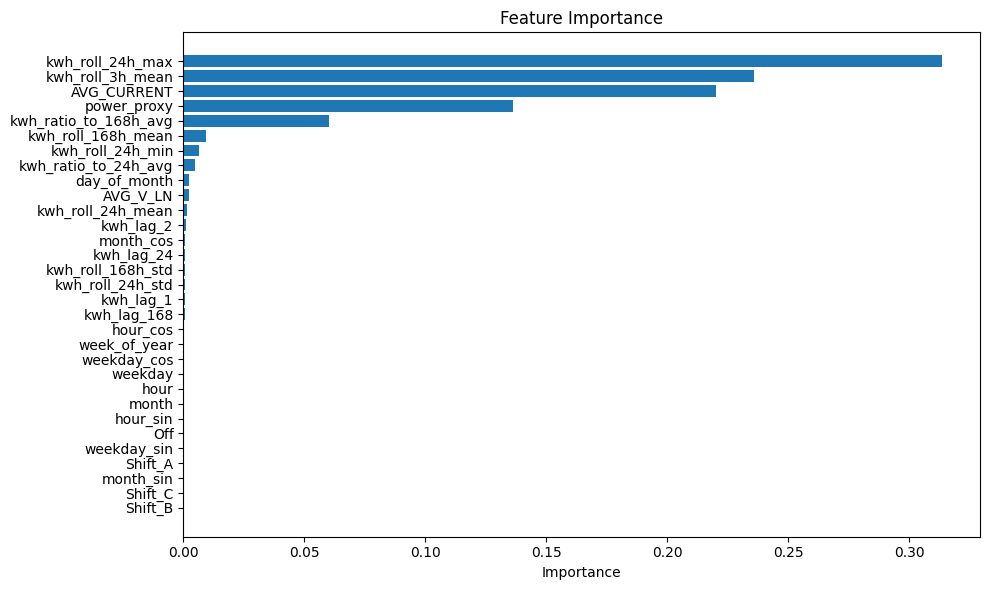

In [45]:
importances = model.feature_importances_
features = X.columns

# Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [47]:
# Ensure datetime index
forecast_df_week.index = pd.to_datetime(forecast_df_week.index)

# Find the Sunday of that week
first_day = forecast_df_week.index.min().normalize()
sunday = first_day + pd.Timedelta(days=(6 - first_day.weekday()) % 7)

# Mask: Sunday 07:00 → Monday 06:00
mask = (
    (forecast_df_week.index >= sunday + pd.Timedelta(hours=7)) &
    (forecast_df_week.index <= sunday + pd.Timedelta(days=1, hours=6))
)

subset = forecast_df_week.loc[mask]

# Plotly Figure
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=subset.index,
    y=subset["Predicted"],   # change if your column name is different
    mode="lines",
    name="Sunday 7AM → Monday 6AM Forecast",
    line=dict(width=2)
))

fig.update_layout(
    title="Hourly Energy Forecast (Sunday 07:00 to Monday 06:00)",
    xaxis_title="Time",
    yaxis_title="Energy / Load",
    template="plotly_white"
)

fig.show()
